aCO2 PFT GPP contribution:
[ 16.20197549 -19.132814   102.93083852]
eCO2 PFT GPP contribution:
[ 72.09128218  77.36018287 -49.45146505]
aCO2 PFT component-to-ecosystem matrix:
[[ 46.50794959 -25.79530743  -4.54896743]
 [-13.93124198 -10.2754667    5.11912379]
 [106.60572134  10.21498901 -14.13319573]]
sum = 99.76360447693055
eCO2 PFT component-to-ecosystem matrix:
[[ 49.91792968  19.87046238   2.23723698]
 [ 43.49140411  31.59453977   2.2037875 ]
 [-64.42337744   8.09580604   6.92114154]]
sum = 99.90893054511503


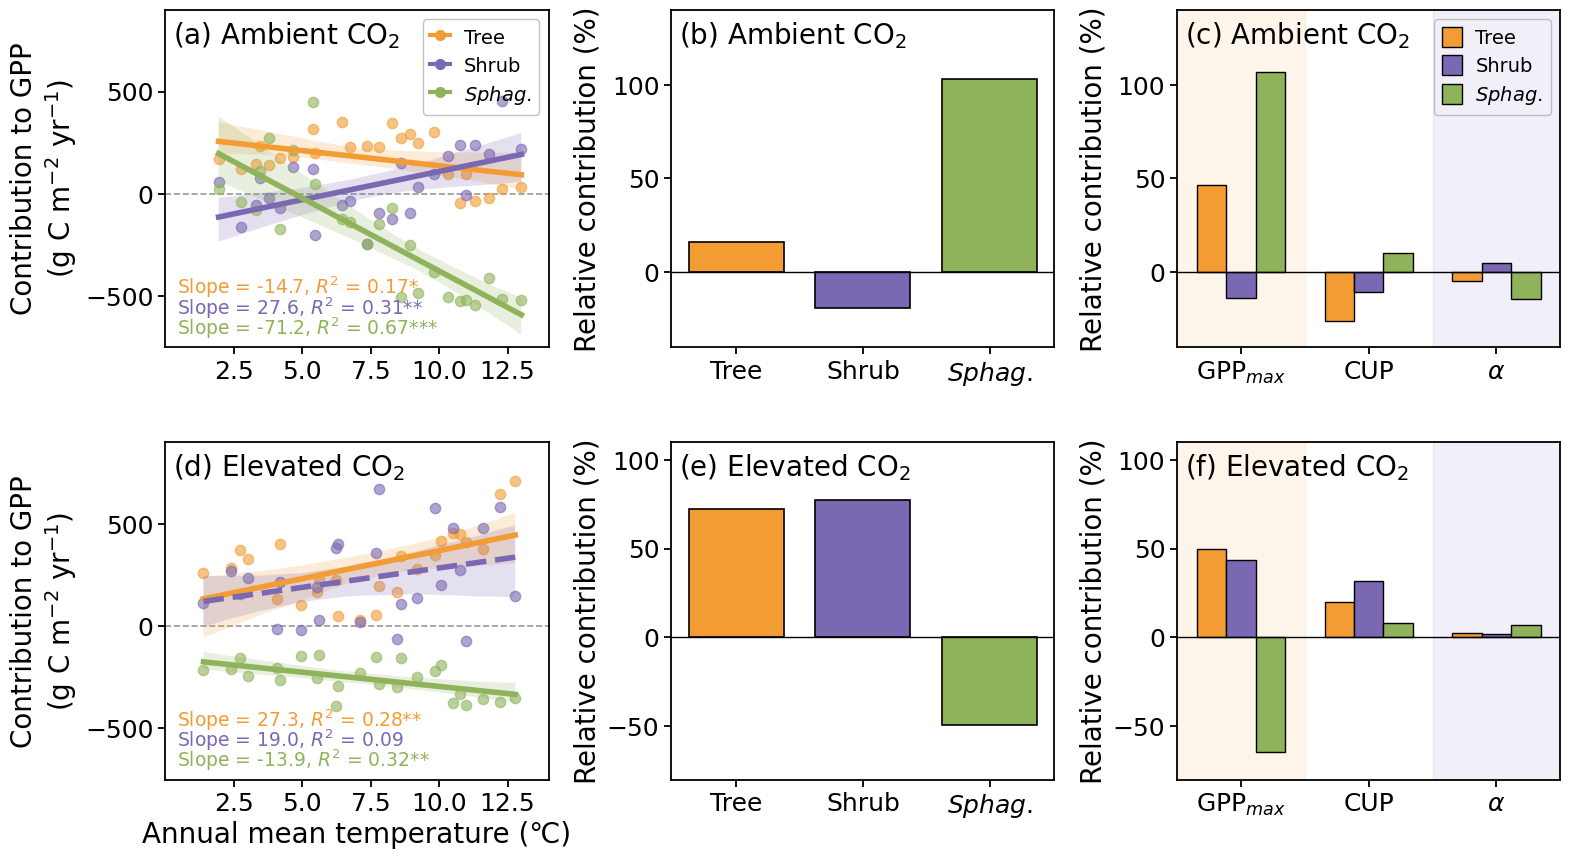

In [1]:
# -*- coding: utf-8 -*-

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns

# ============================================================
# 0) FILE PATHS
# ============================================================
LMDI_DETAIL_FILE = "../../data_results/2_results/2-5_1_contribution_25/all_results_LMDI_detail.xlsx"

CONTRIB_DIR = "../../data_results/2_results/2-5_1_contribution_25/relative_contribution"
FILE_PFT_GPP = os.path.join(CONTRIB_DIR, "signed_PFT_GPP_to_GPP.xlsx")
FILE_PFT_COMP_TO_ECO = os.path.join(
    CONTRIB_DIR,
    "signed_PFT_component_to_ecosystem_GPP.xlsx"
)

# 如果用 absolute contribution，改成：
# FILE_PFT_GPP = os.path.join(CONTRIB_DIR, "abs_PFT_GPP_to_GPP.xlsx")
# FILE_PFT_COMP_TO_ECO = os.path.join(
#     CONTRIB_DIR,
#     "abs_PFT_component_to_ecosystem_GPP.xlsx"
# )

# ============================================================
# 1) CONFIG
# ============================================================
YEAR_MIN = 2016

CO2_COL = "co2"
X_COL = "temp_mean_anom"

ACO2_VALUE = 0
ECO2_VALUE = 500

PFTS = ["tree", "shrub", "sphagnum"]

PFT_LABELS = {
    "tree": "Tree",
    "shrub": "Shrub",
    "sphagnum": r"$\it{Sphag.}$",
}

PFT_COLORS = {
    "tree": "#F39C34",
    "shrub": "#7B68B3",
    "sphagnum": "#8FB35A",
}

COMPONENTS = [
    ("M", "GPP$_{max}$"),
    ("C", "CUP"),
    ("A", r"$\alpha$"),
]

X_TICKS = [2.5, 5, 7.5, 10, 12.5]

GPP_PANEL_YLIM = {
    0: (-750, 900),
    500: (-750, 900),
}

PFT_CONTRIB_YLIM = {
    0: (-40, 140),
    500: (-80, 110),
}

COMP_CONTRIB_YLIM = {
    0: (-40, 140),
    500: (-80, 110),
}

# ============================================================
# 2) HELPERS
# ============================================================
def style_ax(ax, labelsize=14):
    ax.tick_params(
        axis="both", which="major",
        labelsize=labelsize,
        length=5, width=1.3,
        direction="out",
        bottom=True, left=True
    )
    for sp in ax.spines.values():
        sp.set_linewidth(1.3)


def fit_linear(x, y, alpha=0.05):
    x = np.asarray(x, float)
    y = np.asarray(y, float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 3:
        return {
            "slope": np.nan,
            "r2": np.nan,
            "p": np.nan,
            "linestyle": "--",
            "stars": "",
        }

    model = sm.OLS(y, sm.add_constant(x)).fit()
    p = model.pvalues[1]

    stars = (
        "***" if p < 0.001 else
        "**" if p < 0.01 else
        "*" if p < 0.05 else
        ""
    )

    return {
        "slope": float(model.params[1]),
        "r2": float(model.rsquared),
        "p": float(p),
        "linestyle": "-" if p < alpha else "--",
        "stars": stars,
    }


def format_equation(fit):
    if pd.isna(fit["slope"]):
        return "Slope = NA, $R^2$ = NA"

    if fit["r2"] > 0.01:
        return f"Slope = {fit['slope']:.1f}, $R^2$ = {fit['r2']:.2f}{fit['stars']}"
    else:
        return f"Slope = {fit['slope']:.1f}, $R^2$ < 0.01"


def draw_reg(ax, x, y, color, linestyle):
    sns.regplot(
        x=x,
        y=y,
        ax=ax,
        ci=95,
        scatter_kws={
            "alpha": 0.6,
            "color": color,
            "s": 55
        },
        line_kws={
            "linestyle": linestyle,
            "linewidth": 4
        },
        color=color
    )

    if len(ax.collections) > 1:
        ax.collections[-1].set_alpha(0.20)


def get_row_one(df, co2v):
    row = df.loc[df[CO2_COL] == co2v]

    if row.shape[0] != 1:
        raise ValueError(
            f"Expected exactly one row for {CO2_COL}={co2v}, got {row.shape[0]}"
        )

    return row.iloc[0]


def get_pft_gpp_values(df_pft_gpp, co2v):
    row = get_row_one(df_pft_gpp, co2v)

    vals = []

    for pft in PFTS:
        signed_col = f"{pft}_signed_weighted_%"
        abs_col = f"{pft}_mean_%"

        if signed_col in df_pft_gpp.columns:
            col = signed_col
        elif abs_col in df_pft_gpp.columns:
            col = abs_col
        else:
            raise KeyError(
                f"Missing PFT GPP contribution column for {pft}. "
                f"Expected {signed_col} or {abs_col}"
            )

        vals.append(float(row[col]))

    return np.asarray(vals, float)


def get_pft_component_to_eco_matrix(df_comp_to_eco, co2v):
    """
    Matrix:
        rows = tree, shrub, sphagnum
        cols = M, C, A

    Uses new file:
        signed_PFT_component_to_ecosystem_GPP.xlsx

    Columns:
        tree_M_signed_toEco_%
        tree_C_signed_toEco_%
        tree_A_signed_toEco_%
        ...
    """
    row = get_row_one(df_comp_to_eco, co2v)

    mat = np.zeros((len(PFTS), len(COMPONENTS)), float)

    for i, pft in enumerate(PFTS):
        for j, (comp, _) in enumerate(COMPONENTS):

            signed_col = f"{pft}_{comp}_signed_toEco_%"
            abs_mean_col = f"{pft}_{comp}_abs_toEco_%_mean"

            if signed_col in df_comp_to_eco.columns:
                col = signed_col
            elif abs_mean_col in df_comp_to_eco.columns:
                col = abs_mean_col
            else:
                raise KeyError(
                    f"Missing component-to-ecosystem column for {pft}-{comp}. "
                    f"Expected {signed_col} or {abs_mean_col}"
                )

            mat[i, j] = float(row[col])

    return mat


# ============================================================
# 3) PLOT FUNCTIONS
# ============================================================
def plot_pft_gpp_response(ax, df_lmdi, co2_value, panel_title, ylabel=None, xlabel=None):
    """
    Left column:
    PFT contribution to ecosystem GPP change vs temperature.

    Uses:
        tree_dGPP
        shrub_dGPP
        sphagnum_dGPP
    """
    ax.text(
        0.02, 0.97,
        panel_title,
        transform=ax.transAxes,
        fontsize=20,
        va="top",
        ha="left"
    )

    ax.set_xlim(0, 14)
    ax.set_xticks(X_TICKS)
    ax.set_ylim(GPP_PANEL_YLIM[co2_value])

    ax.axhline(
        0,
        color="gray",
        linewidth=1.2,
        linestyle="--",
        alpha=0.8,
        zorder=0
    )

    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=20)

    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize=20)

    eq_positions = {
        "tree": (0.03, 0.14),
        "shrub": (0.03, 0.08),
        "sphagnum": (0.03, 0.02),
    }

    d0 = df_lmdi[df_lmdi[CO2_COL] == co2_value].copy()

    for pft in PFTS:
        y_col = f"{pft}_dGPP"

        if y_col not in d0.columns:
            raise KeyError(f"Missing column in LMDI detail file: {y_col}")

        x = d0[X_COL].to_numpy(float)
        y = d0[y_col].to_numpy(float)

        fit = fit_linear(x, y)

        draw_reg(
            ax,
            x,
            y,
            color=PFT_COLORS[pft],
            linestyle=fit["linestyle"]
        )

        tx, ty = eq_positions[pft]

        ax.text(
            tx,
            ty,
            format_equation(fit),
            fontsize=13.5,
            transform=ax.transAxes,
            color=PFT_COLORS[pft],
            va="bottom"
        )

    style_ax(ax, labelsize=18)


def plot_pft_gpp_contribution(ax, vals, co2_value, panel_title, ylabel=None):
    """
    Middle column:
    PFT relative contribution to ecosystem GPP response.
    """
    x = np.arange(len(PFTS))
    colors = [PFT_COLORS[pft] for pft in PFTS]
    labels = [PFT_LABELS[pft] for pft in PFTS]

    ax.bar(
        x,
        vals,
        color=colors,
        edgecolor="black",
        linewidth=1.2,
        width=0.75
    )

    ax.axhline(0, color="k", lw=1)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=18)
    ax.set_ylim(PFT_CONTRIB_YLIM[co2_value])

    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=20)

    ax.text(
        0.02, 0.97,
        panel_title,
        transform=ax.transAxes,
        fontsize=20,
        va="top",
        ha="left"
    )

    style_ax(ax, labelsize=18)


def add_group_backgrounds(ax):
    ax.axvspan(-0.5, 0.5, color="#F39C34", alpha=0.10, zorder=0)
    ax.axvspan(1.5, 2.5, color="#7B68B3", alpha=0.10, zorder=0)


def plot_component_grouped_bars(ax, mat, co2_value, panel_title, ylabel=None):
    """
    Right column:
    PFT components directly contributing to ecosystem GPP response.

    x groups:
        GPPmax, CUP, alpha

    bars:
        Tree, Shrub, Sphagnum
    """
    x_group = np.arange(len(COMPONENTS))
    width = 0.23

    ax.set_xlim(-0.5, 2.5)
    add_group_backgrounds(ax)

    for i, pft in enumerate(PFTS):
        vals = mat[i, :]
        xpos = x_group + (i - 1) * width

        ax.bar(
            xpos,
            vals,
            width=width,
            color=PFT_COLORS[pft],
            edgecolor="black",
            linewidth=1.0,
            label=PFT_LABELS[pft]
        )

    ax.axhline(0, color="k", lw=1)

    ax.set_xticks(x_group)
    ax.set_xticklabels([lab for _, lab in COMPONENTS], fontsize=18)
    ax.set_ylim(COMP_CONTRIB_YLIM[co2_value])

    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=20)

    ax.text(
        0.02, 0.97,
        panel_title,
        transform=ax.transAxes,
        fontsize=20,
        va="top",
        ha="left"
    )

    style_ax(ax, labelsize=18)


# ============================================================
# 4) READ DATA
# ============================================================
df_lmdi = pd.read_excel(LMDI_DETAIL_FILE)
df_lmdi = df_lmdi[df_lmdi["year"] > YEAR_MIN].copy()

df_pft_gpp = pd.read_excel(FILE_PFT_GPP)
df_comp_to_eco = pd.read_excel(FILE_PFT_COMP_TO_ECO)

required_lmdi_cols = [
    CO2_COL,
    X_COL,
    "tree_dGPP",
    "shrub_dGPP",
    "sphagnum_dGPP",
]

missing = [c for c in required_lmdi_cols if c not in df_lmdi.columns]
if missing:
    raise KeyError(f"Missing columns in LMDI detail file: {missing}")

# PFT total contribution to ecosystem GPP
vals_a = get_pft_gpp_values(df_pft_gpp, ACO2_VALUE)
vals_e = get_pft_gpp_values(df_pft_gpp, ECO2_VALUE)

# PFT component contribution directly to ecosystem GPP
mat_a = get_pft_component_to_eco_matrix(df_comp_to_eco, ACO2_VALUE)
mat_e = get_pft_component_to_eco_matrix(df_comp_to_eco, ECO2_VALUE)

print("aCO2 PFT GPP contribution:")
print(vals_a)

print("eCO2 PFT GPP contribution:")
print(vals_e)

print("aCO2 PFT component-to-ecosystem matrix:")
print(mat_a)
print("sum =", np.nansum(mat_a))

print("eCO2 PFT component-to-ecosystem matrix:")
print(mat_e)
print("sum =", np.nansum(mat_e))

# ============================================================
# 5) 2 x 3 FIGURE
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
plt.subplots_adjust(hspace=0.28, wspace=0.32)

ax_a, ax_b, ax_c = axes[0, :]
ax_d, ax_e, ax_f = axes[1, :]

# ------------------------------------------------------------
# Row 1: Ambient CO2
# ------------------------------------------------------------
plot_pft_gpp_response(
    ax_a,
    df_lmdi=df_lmdi,
    co2_value=ACO2_VALUE,
    panel_title="(a) Ambient CO$_2$",
    ylabel="Contribution to GPP\n(g C m$^{-2}$ yr$^{-1}$)"
)

plot_pft_gpp_contribution(
    ax_b,
    vals=vals_a,
    co2_value=ACO2_VALUE,
    panel_title="(b) Ambient CO$_2$",
    ylabel="Relative contribution (%)"
)

plot_component_grouped_bars(
    ax_c,
    mat=mat_a,
    co2_value=ACO2_VALUE,
    panel_title="(c) Ambient CO$_2$",
    ylabel="Relative contribution (%)"
)

# ------------------------------------------------------------
# Row 2: Elevated CO2
# ------------------------------------------------------------
plot_pft_gpp_response(
    ax_d,
    df_lmdi=df_lmdi,
    co2_value=ECO2_VALUE,
    panel_title="(d) Elevated CO$_2$",
    ylabel="Contribution to GPP\n(g C m$^{-2}$ yr$^{-1}$)",
    xlabel="Annual mean temperature (℃)"
)

plot_pft_gpp_contribution(
    ax_e,
    vals=vals_e,
    co2_value=ECO2_VALUE,
    panel_title="(e) Elevated CO$_2$",
    ylabel="Relative contribution (%)"
)

plot_component_grouped_bars(
    ax_f,
    mat=mat_e,
    co2_value=ECO2_VALUE,
    panel_title="(f) Elevated CO$_2$",
    ylabel="Relative contribution (%)"
)

# ============================================================
# 6) LEGENDS
# ============================================================
gpp_handles = []

for pft in PFTS:
    h = plt.Line2D(
        [0],
        [0],
        color=PFT_COLORS[pft],
        marker="o",
        linestyle="-",
        linewidth=3,
        markersize=7,
        label=PFT_LABELS[pft]
    )
    gpp_handles.append(h)

leg1 = ax_a.legend(
    handles=gpp_handles,
    loc="upper right",
    fontsize=14,
    frameon=True,
    handlelength=1.0,
    handleheight=1.2,
    handletextpad=0.7,
    labelspacing=0.4,
    borderpad=0.4
)

leg1.get_frame().set_facecolor("none")
leg1.get_frame().set_edgecolor("0.7")

leg2 = ax_c.legend(
    loc="upper right",
    fontsize=14,
    frameon=True,
    handlelength=1.0,
    handleheight=1.2,
    handletextpad=0.7,
    labelspacing=0.4,
    borderpad=0.4
)

leg2.get_frame().set_facecolor("none")
leg2.get_frame().set_edgecolor("0.7")

# ============================================================
# 7) FINAL
# ============================================================
fig.align_ylabels()
plt.show()